# 2409106002 - Renaya Putri Alika - POSTTEST2 - Kecerdasan Buatan
## Tema: Campus Student Placement
### Faktor-Faktor yang Mempengaruhi Penempatan Kerja Mahasiswa di Kampus

Notebook ini berisi eksplorasi data (EDA) terhadap dataset **Factors Affecting Campus Placement** yang diambil dari Kaggle:

https://www.kaggle.com/datasets/benroshan/factors-affecting-campus-placement/data

Dataset ini berisi data akademik dan non-akademik mahasiswa seperti nilai SMP/SMA, nilai kuliah, pengalaman kerja, nilai tes kerja, dan status penempatan kerja setelah lulus.

Dataset terdiri dari **215 baris (record)** dan **15 kolom (atribut)**.

| Kolom | Keterangan |
|---|---|
| sl_no | Nomor urut data |
| gender | Jenis kelamin (M/F) |
| ssc_p | Nilai ujian SMP (%) |
| ssc_b | Jenis penyelenggara pendidikan SMP (Central/Others) |
| hsc_p | Nilai ujian SMA (%) |
| hsc_b | Jenis penyelenggara pendidikan SMA (Central/Others) |
| hsc_s | Jurusan saat SMA (Science/Commerce/Arts) |
| degree_p | Nilai kelulusan S1 (%) |
| degree_t | Bidang studi S1 (Sci&Tech/Comm&Mgmt/Others) |
| workex | Pengalaman kerja sebelumnya (Yes/No) |
| etest_p | Nilai tes kerja (employability test) (%) |
| specialisation | Spesialisasi MBA (Mkt&HR/Mkt&Fin) |
| mba_p | Nilai MBA (%) |
| status | Status penempatan kerja (Placed/Not Placed) |
| salary | Gaji yang diterima (hanya terisi jika status = Placed) |

## 1. Memuat Dataset

Dataset diunduh langsung dari Kaggle menggunakan library `kagglehub`, kemudian dibaca menggunakan `pandas`.

In [27]:
!pip install kagglehub -q

In [28]:
import kagglehub
import os

# Mengunduh dataset 'Factors Affecting Campus Placement' dari Kaggle
path = kagglehub.dataset_download(
    "benroshan/factors-affecting-campus-placement"
)

print("Dataset tersimpan di:", path)
print("Isi folder:", os.listdir(path))

Dataset tersimpan di: /Users/renayaputri81gmail.com/.cache/kagglehub/datasets/benroshan/factors-affecting-campus-placement/versions/1
Isi folder: ['Placement_Data_Full_Class.csv']


Catatan: Jika perintah `kagglehub.dataset_download` gagal dijalankan, dataset bisa diunduh manual dari link Kaggle kemudian nama file CSV disesuaikan pada bagian `pd.read_csv()`.

In [29]:
import pandas as pd

# Nama file csv di dalam dataset Kaggle ini adalah 'Placement_Data_Full_Class.csv'
file_csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]

dataFrame = pd.read_csv(
    os.path.join(path, file_csv)
)

dataFrame.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## 2. Informasi Umum Dataset

Bagian ini menampilkan jumlah record, jumlah atribut, nama-nama atribut, tipe data setiap atribut, serta jumlah atribut yang bertipe angka (numerik).

In [30]:
dataFrame.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [31]:
jumlah_record, jumlah_atribut = dataFrame.shape

print(f"Jumlah record  : {jumlah_record}")
print(f"Jumlah atribut : {jumlah_atribut}")
print(f"Nama atribut   : {list(dataFrame.columns)}")

Jumlah record  : 215
Jumlah atribut : 15
Nama atribut   : ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


In [32]:
# Memisahkan atribut berdasarkan tipe data
atribut_numerik = dataFrame.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

atribut_kategorikal = dataFrame.select_dtypes(
    include=['object']
).columns.tolist()

print(f"Jumlah atribut bertipe angka (numerik) : {len(atribut_numerik)}")
print(f"Nama atribut numerik                   : {atribut_numerik}")
print()

print(f"Jumlah atribut bertipe object (kategorikal) : {len(atribut_kategorikal)}")
print(f"Nama atribut kategorikal                    : {atribut_kategorikal}")

Jumlah atribut bertipe angka (numerik) : 7
Nama atribut numerik                   : ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Jumlah atribut bertipe object (kategorikal) : 8
Nama atribut kategorikal                    : ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_87542/3672194545.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  atribut_kategorikal = dataFrame.select_dtypes(


## 3. Statistik Deskriptif Atribut Numerik

Menampilkan rata-rata (mean), standar deviasi (std), nilai minimum, nilai maksimum, kuartil 1 (Q1 / 25%), kuartil 2 (Q2 / median / 50%), dan kuartil 3 (Q3 / 75%) untuk setiap atribut bertipe angka.

In [33]:
statistik_deskriptif = dataFrame[
    atribut_numerik
].describe().T

# describe() secara otomatis menghitung count, mean, std,
# min, 25% (Q1), 50% (Q2), 75% (Q3), dan max
statistik_deskriptif[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

,mean,std,min,25%,50%,75%,max
sl_no,108.000000,62.209324,1.00,54.500,108.0,161.500,215.00
ssc_p,67.303395,10.827205,40.89,60.600,67.0,75.700,89.40
hsc_p,66.333163,10.897509,37.00,60.900,65.0,73.000,97.70
degree_p,66.370186,7.358743,50.00,61.000,66.0,72.000,91.00
etest_p,72.100558,13.275956,50.00,60.000,71.0,83.500,98.00
mba_p,62.278186,5.833385,51.21,57.945,62.0,66.255,77.89
salary,288655.405405,93457.452420,200000.00,240000.000,265000.0,300000.000,940000.00


## 4. 10 Record Pertama (Atribut Numerik)

Menampilkan 10 baris data pertama, hanya untuk kolom-kolom yang bertipe angka.

In [34]:
dataFrame[
    atribut_numerik
].head(10)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,1,67.00,91.00,58.00,55.00,58.80,270000.0
1,2,79.33,78.33,77.48,86.50,66.28,200000.0
2,3,65.00,68.00,64.00,75.00,57.80,250000.0
3,4,56.00,52.00,52.00,66.00,59.43,NaN
4,5,85.80,73.60,73.30,96.80,55.50,425000.0
5,6,55.00,49.80,67.25,55.00,51.58,NaN
6,7,46.00,49.20,79.00,74.28,53.29,NaN
7,8,82.00,64.00,66.00,67.00,62.14,252000.0
8,9,73.00,79.00,72.00,91.34,61.29,231000.0
9,10,58.00,70.00,61.00,54.00,52.21,NaN


## 5. Jumlah Label pada Setiap Atribut Kategorikal (Object)

Menampilkan jumlah label/kategori unik untuk setiap atribut bertipe object, beserta rincian jumlah data pada masing-masing label.

In [35]:
for kolom in atribut_kategorikal:
    jumlah_label = dataFrame[kolom].nunique()

    print(f"Atribut '{kolom}' memiliki {jumlah_label} label:")
    print(dataFrame[kolom].value_counts())
    print("-" * 40)

Atribut 'gender' memiliki 2 label:
gender
M    139
F     76
Name: count, dtype: int64
----------------------------------------
Atribut 'ssc_b' memiliki 2 label:
ssc_b
Central    116
Others      99
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_b' memiliki 2 label:
hsc_b
Others     131
Central     84
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_s' memiliki 3 label:
hsc_s
Commerce    113
Science      91
Arts         11
Name: count, dtype: int64
----------------------------------------
Atribut 'degree_t' memiliki 3 label:
degree_t
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: count, dtype: int64
----------------------------------------
Atribut 'workex' memiliki 2 label:
workex
No     141
Yes     74
Name: count, dtype: int64
----------------------------------------
Atribut 'specialisation' memiliki 2 label:
specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64
-----------------------------------

In [36]:
# Ringkasan jumlah label tiap atribut kategorikal dalam bentuk tabel
ringkasan_label = pd.DataFrame({
    'Atribut': atribut_kategorikal,
    'Jumlah Label': [
        dataFrame[kolom].nunique()
        for kolom in atribut_kategorikal
    ]
})

ringkasan_label

,Atribut,Jumlah Label
0,gender,2
1,ssc_b,2
2,hsc_b,2
3,hsc_s,3
4,degree_t,3
5,workex,2
6,specialisation,2
7,status,2


## 6. Visualisasi Data

Berikut ditampilkan dua jenis grafik untuk membantu memahami sebaran dan pola pada dataset.

### 6.1 Histogram - Sebaran Nilai Akademik (Atribut Numerik)

Histogram digunakan untuk melihat sebaran (distribusi) dari atribut numerik seperti nilai SMP, SMA, kuliah, tes kerja, dan MBA.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

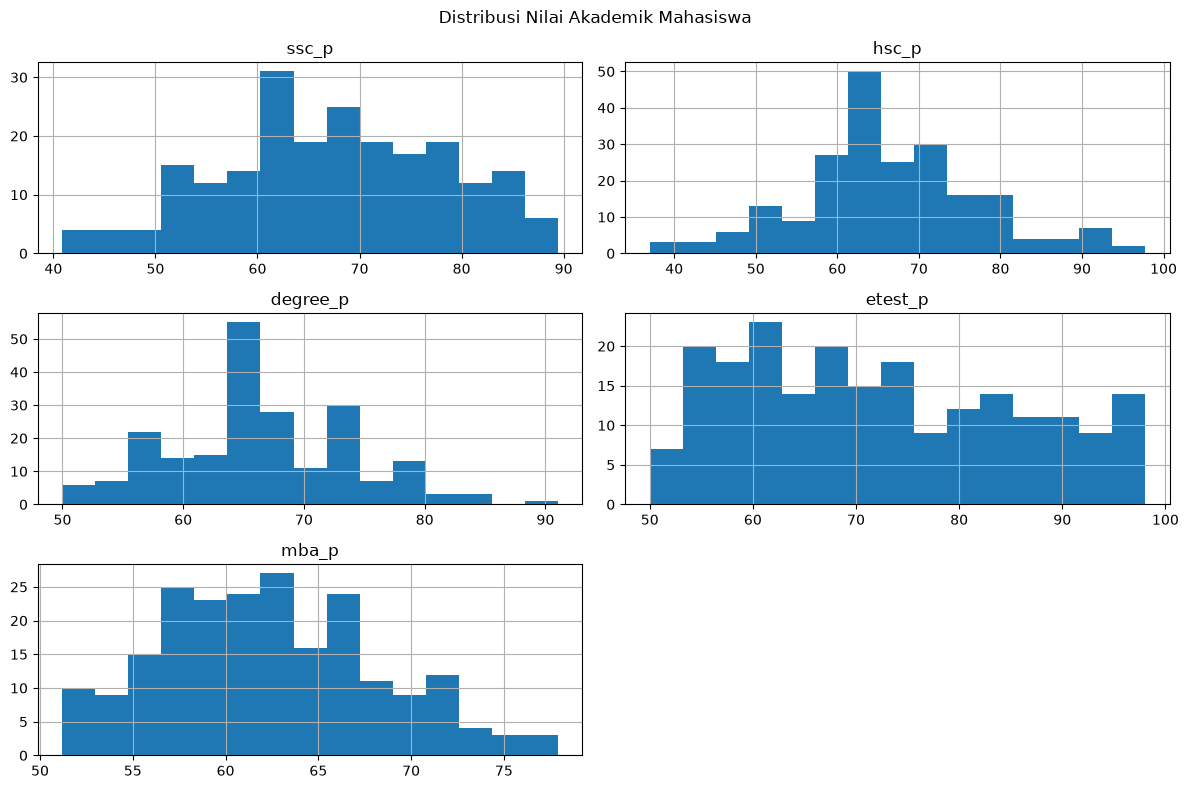

In [38]:
kolom_nilai = [
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]

dataFrame[
    kolom_nilai
].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle(
    'Distribusi Nilai Akademik Mahasiswa'
)

plt.tight_layout()
plt.show()

### 6.2 Bar Chart - Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja

Bar chart digunakan untuk melihat perbandingan jumlah mahasiswa yang berhasil ditempatkan kerja (`Placed`) dan yang tidak (`Not Placed`).

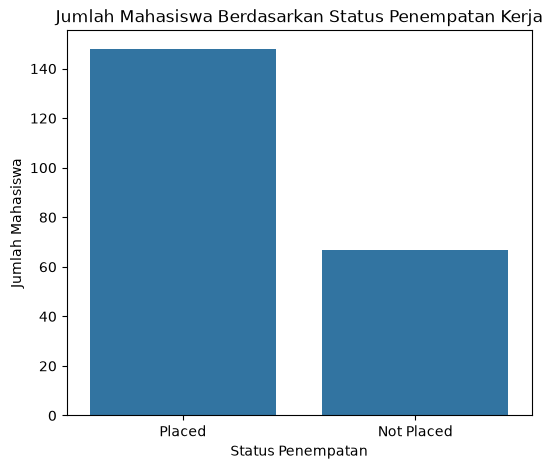

In [39]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=dataFrame,
    x='status'
)

plt.title(
    'Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja'
)

plt.xlabel('Status Penempatan')
plt.ylabel('Jumlah Mahasiswa')

plt.show()

### 6.3 (Tambahan) Boxplot - Nilai MBA Berdasarkan Status Penempatan

Sebagai tambahan eksplorasi, boxplot digunakan untuk membandingkan sebaran nilai MBA (`mba_p`) antara mahasiswa yang ditempatkan kerja dan yang tidak.

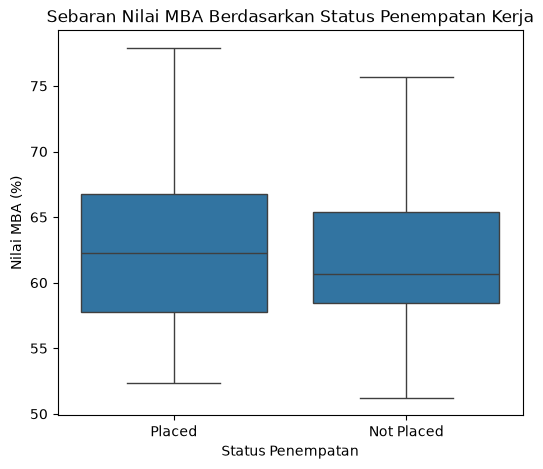

In [40]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=dataFrame,
    x='status',
    y='mba_p'
)

plt.title(
    'Sebaran Nilai MBA Berdasarkan Status Penempatan Kerja'
)

plt.xlabel('Status Penempatan')
plt.ylabel('Nilai MBA (%)')

plt.show()

## 7. Korelasi Antar Atribut Numerik (Heatmap)

Heatmap berikut menampilkan nilai korelasi antar atribut numerik dalam dataset. Nilai korelasi berkisar dari -1 hingga 1.

In [41]:
matriks_korelasi = dataFrame[
    atribut_numerik
].corr()

matriks_korelasi

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.063764
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.063764,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


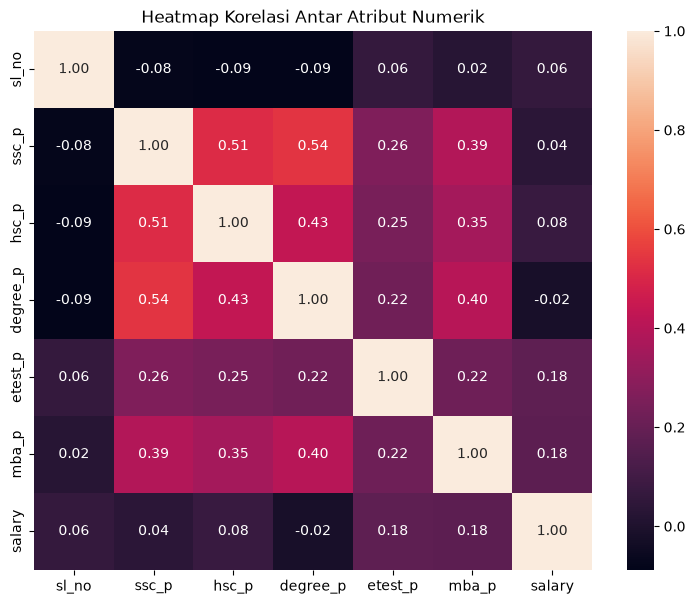

In [42]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt='.2f'
)

plt.title(
    'Heatmap Korelasi Antar Atribut Numerik'
)

plt.show()

Dari heatmap di atas dapat dilihat pola korelasi antar nilai akademik mahasiswa, misalnya hubungan antara nilai SMP (`ssc_p`), SMA (`hsc_p`), nilai kuliah (`degree_p`), nilai tes kerja (`etest_p`), dan nilai MBA (`mba_p`).

## 8. Kesimpulan Sementara

Berdasarkan eksplorasi data di atas, dapat disimpulkan sementara bahwa:

1. Dataset terdiri dari 215 record dan 15 atribut, dengan atribut numerik dan kategorikal.

2. Status penempatan kerja terdiri dari `Placed` dan `Not Placed`.

3. Atribut nilai akademik dapat dilihat distribusinya menggunakan histogram.

4. Grafik batang dapat digunakan untuk membandingkan jumlah mahasiswa berdasarkan status penempatan kerja.

5. Boxplot dapat digunakan untuk melihat persebaran nilai MBA berdasarkan status penempatan.

6. Heatmap digunakan untuk melihat hubungan antar atribut numerik.

# 9. Data Preprocessing

Ketentuan preprocessing yang perlu dikerjakan adalah:

1. Data Cleaning
   - Handling missing value
   - Handling duplicate value
   - Handling outlier
2. Normalisasi/standarisasi kolom numerik
3. Encoding kolom kategorikal
4. Feature engineering minimal 1 feature baru dan tidak menyentuh target label

**Catatan:** Bagian ini sengaja belum diisi dengan teknik atau library tambahan agar metode preprocessing yang digunakan tetap mengikuti modul yang diberikan dosen.

Pada tahap ini dilakukan pra-pemrosesan data untuk membersihkan dan mengubah data agar lebih siap digunakan dalam analisis atau machine learning. 

Tahapan yang dilakukan adalah data cleaning, transformasi data, encoding, dan feature engineering.


### 9.1 Mengecek Missing Value

Sebelum menangani data yang hilang, dilakukan pengecekan terlebih dahulu menggunakan `isnull().sum()`.

Jika terdapat missing value, penanganannya disesuaikan dengan jenis datanya.


In [43]:
# Mengecek jumlah missing value pada setiap kolom
dataFrame.isnull().sum()


sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Pada dataset ini, kolom `salary` memiliki nilai kosong karena informasi gaji hanya tersedia untuk mahasiswa yang berstatus `Placed`. Nilai kosong tersebut tidak langsung dianggap sebagai kesalahan data.

Untuk kebutuhan preprocessing, kolom `salary` tidak digunakan sebagai fitur karena informasi tersebut berkaitan dengan hasil placement.


### 9.2 Mengecek Data Duplikat

Data duplikat perlu diperiksa karena data yang sama lebih dari satu kali dapat mempengaruhi hasil analisis.


In [44]:
# Mengecek jumlah data duplikat
dataFrame.duplicated().sum()


np.int64(0)

In [45]:
# Menghapus data duplikat jika ditemukan
dataFrame = dataFrame.drop_duplicates()

# Mengecek kembali jumlah data duplikat
dataFrame.duplicated().sum()


np.int64(0)

### 9.3 Handling Outlier

Outlier merupakan nilai yang berbeda jauh dari sebagian besar data. Pada tahap ini digunakan metode IQR (Interquartile Range).

Outlier dicek pada atribut numerik. Jika ditemukan nilai di luar batas IQR, data tersebut akan ditangani.


In [46]:
# Menentukan kolom numerik yang akan diperiksa outlier
kolom_outlier = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

# Mengecek jumlah outlier menggunakan metode IQR
for kolom in kolom_outlier:
    Q1 = dataFrame[kolom].quantile(0.25)
    Q3 = dataFrame[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    jumlah_outlier = (
        (dataFrame[kolom] < batas_bawah) |
        (dataFrame[kolom] > batas_atas)
    ).sum()

    print(kolom, ":", jumlah_outlier, "outlier")


ssc_p : 0 outlier
hsc_p : 8 outlier
degree_p : 1 outlier
etest_p : 0 outlier
mba_p : 0 outlier


Berdasarkan pengecekan IQR, outlier ditangani hanya jika ditemukan. Nilai yang masih berada dalam batas IQR dipertahankan karena masih termasuk dalam rentang data.


## 10. Normalisasi Data Numerik

Normalisasi digunakan untuk mengubah skala data sehingga nilainya berada pada rentang tertentu, yaitu 0 sampai 1.

Pada dataset ini, normalisasi diterapkan pada atribut numerik yang digunakan sebagai fitur.


In [47]:
# Kolom numerik yang akan dinormalisasi
kolom_normalisasi = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

# Normalisasi Min-Max
for kolom in kolom_normalisasi:
    nilai_min = dataFrame[kolom].min()
    nilai_max = dataFrame[kolom].max()

    dataFrame[kolom] = (
        (dataFrame[kolom] - nilai_min) /
        (nilai_max - nilai_min)
    )

# Menampilkan hasil normalisasi
dataFrame[kolom_normalisasi].head()


,ssc_p,hsc_p,degree_p,etest_p,mba_p
0,0.538240,0.889621,0.195122,0.104167,0.284483
1,0.792414,0.680890,0.670244,0.760417,0.564843
2,0.497011,0.510708,0.341463,0.520833,0.247001
3,0.311482,0.247117,0.048780,0.333333,0.308096
4,0.925788,0.602965,0.568293,0.975000,0.160795


Normalisasi dilakukan dengan metode Min-Max agar skala atribut numerik menjadi lebih seragam. (Scaling)


## 11. Encoding Kolom Kategorikal

Encoding dilakukan untuk mengubah data kategorikal menjadi bentuk numerik agar dapat digunakan oleh algoritma machine learning.

Kolom kategorikal yang tidak memiliki urutan alami menggunakan One-Hot Encoding.


In [48]:
# Melihat kolom kategorikal
atribut_kategorikal = dataFrame.select_dtypes(include="object").columns.tolist()

atribut_kategorikal


/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_87542/4171820970.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  atribut_kategorikal = dataFrame.select_dtypes(include="object").columns.tolist()


['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

Pada dataset Campus Placement, kategori seperti gender, board, stream, degree type, work experience, specialization, dan status tidak memiliki urutan alami.

Oleh karena itu, encoding yang digunakan adalah One-Hot Encoding.


In [49]:
# One-Hot Encoding untuk kolom kategorikal
dataFrame = pd.get_dummies(
    dataFrame,
    columns=[
        "gender",
        "ssc_b",
        "hsc_b",
        "hsc_s",
        "degree_t",
        "workex",
        "specialisation"
    ]
)

# Menampilkan data setelah encoding
dataFrame.head()


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_F,gender_M,...,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,0.538240,0.889621,0.195122,0.104167,0.284483,Placed,270000.0,False,True,...,False,True,False,False,False,True,True,False,False,True
1,2,0.792414,0.680890,0.670244,0.760417,0.564843,Placed,200000.0,False,True,...,False,False,True,False,False,True,False,True,True,False
2,3,0.497011,0.510708,0.341463,0.520833,0.247001,Placed,250000.0,False,True,...,True,False,False,True,False,False,True,False,True,False
3,4,0.311482,0.247117,0.048780,0.333333,0.308096,Not Placed,NaN,False,True,...,False,False,True,False,False,True,True,False,False,True
4,5,0.925788,0.602965,0.568293,0.975000,0.160795,Placed,425000.0,False,True,...,False,True,False,True,False,False,True,False,True,False


Kolom `status` tidak diubah menjadi fitur karena `status` merupakan target label pada dataset. Dengan demikian, target tetap dipisahkan dari fitur.


## 12. Feature Engineering

Feature engineering dilakukan dengan membuat fitur baru dari atribut yang sudah tersedia.

Fitur baru yang dibuat adalah `academic_average`, yaitu rata-rata nilai `ssc_p`, `hsc_p`, dan `degree_p`. Fitur ini tidak menggunakan target `status`.


In [50]:
# Membuat fitur baru berupa rata-rata nilai akademik
dataFrame["academic_average"] = (
    dataFrame["ssc_p"] +
    dataFrame["hsc_p"] +
    dataFrame["degree_p"]
) / 3

# Menampilkan fitur baru
dataFrame[[
    "ssc_p",
    "hsc_p",
    "degree_p",
    "academic_average"
]].head()


,ssc_p,hsc_p,degree_p,academic_average
0,0.538240,0.889621,0.195122,0.540994
1,0.792414,0.680890,0.670244,0.714516
2,0.497011,0.510708,0.341463,0.449728
3,0.311482,0.247117,0.048780,0.202460
4,0.925788,0.602965,0.568293,0.699016


Fitur `academic_average` dibuat untuk merangkum tiga nilai akademik menjadi satu atribut baru. Pembuatan fitur ini tidak menggunakan `status`, sehingga tidak menyentuh target label.


## 13. Hasil Akhir Data Preprocessing

Setelah proses cleaning, normalisasi, encoding, dan feature engineering dilakukan, data dapat diperiksa kembali untuk melihat bentuk akhirnya.


In [51]:
# Melihat ukuran dataset setelah preprocessing
print("Jumlah baris :", dataFrame.shape[0])
print("Jumlah kolom :", dataFrame.shape[1])

# Menampilkan data hasil preprocessing
dataFrame.head()


Jumlah baris : 215
Jumlah kolom : 25


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,salary,gender_F,gender_M,...,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR,academic_average
0,1,0.538240,0.889621,0.195122,0.104167,0.284483,Placed,270000.0,False,True,...,True,False,False,False,True,True,False,False,True,0.540994
1,2,0.792414,0.680890,0.670244,0.760417,0.564843,Placed,200000.0,False,True,...,False,True,False,False,True,False,True,True,False,0.714516
2,3,0.497011,0.510708,0.341463,0.520833,0.247001,Placed,250000.0,False,True,...,False,False,True,False,False,True,False,True,False,0.449728
3,4,0.311482,0.247117,0.048780,0.333333,0.308096,Not Placed,NaN,False,True,...,False,True,False,False,True,True,False,False,True,0.202460
4,5,0.925788,0.602965,0.568293,0.975000,0.160795,Placed,425000.0,False,True,...,True,False,True,False,False,True,False,True,False,0.699016


In [52]:
# Melihat informasi dataset setelah preprocessing
dataFrame.info()


<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sl_no                   215 non-null    int64  
 1   ssc_p                   215 non-null    float64
 2   hsc_p                   215 non-null    float64
 3   degree_p                215 non-null    float64
 4   etest_p                 215 non-null    float64
 5   mba_p                   215 non-null    float64
 6   status                  215 non-null    str    
 7   salary                  148 non-null    float64
 8   gender_F                215 non-null    bool   
 9   gender_M                215 non-null    bool   
 10  ssc_b_Central           215 non-null    bool   
 11  ssc_b_Others            215 non-null    bool   
 12  hsc_b_Central           215 non-null    bool   
 13  hsc_b_Others            215 non-null    bool   
 14  hsc_s_Arts              215 non-null    bool   
 15  

### Kesimpulan

Pada tahap preprocessing, dataset telah diperiksa dari missing value, data duplikat, dan outlier. Selanjutnya atribut numerik dinormalisasi menggunakan Min-Max Scaling, atribut kategorikal diubah menggunakan One-Hot Encoding, dan dibuat satu fitur baru yaitu `academic_average`.

Tahapan tersebut dilakukan agar data lebih terstruktur dan siap digunakan untuk tahap analisis atau machine learning berikutnya.
